# 07. CCI 가중치 민감도 분석
## 방법론 안정성 검증 — Sensitivity Analysis

**분석 목적**: 가중치가 달라지더라도 고위험 지역이 안정적으로 식별되는지 검증합니다.

**메인 시나리오 가중치 근거 (AHP 기반)**

| 지표 | 가중치 | 근거 |
|------|--------|------|
| IVI (사회적 고립) | **0.40** | 인적 취약성이 피해 규모 예측에 가장 결정적 (Cutter et al., 2003) |
| RII (강우·침수) | **0.35** | 논문 주제 맥락('비가 오면')의 재난 특수성 반영 |
| CDI (생활 인프라) | **0.25** | 강우 시 이동 불가로 위기를 증폭하는 보조 요인 |

| 시나리오 | IVI | CDI | RII | 의미 |
|----------|-----|-----|-----|------|
| Main | 0.40 | 0.25 | 0.35 | AHP 기반 메인 |
| S1 Equal | 0.33 | 0.33 | 0.33 | 균등 가중치 |
| S2 IVI-heavy | 0.50 | 0.25 | 0.25 | 사회적 고립 집중 |
| S3 RII-heavy | 0.30 | 0.20 | 0.50 | 침수 위험 집중 |

---
## 1. 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy.stats import kendalltau
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

BASE_DIR   = Path('c:/Tsum2026/T_SUM2026')
OUTPUT_DIR = BASE_DIR / 'data' / 'output'
FIG_DIR    = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(OUTPUT_DIR / 'final_crisis_index_by_dong_2021.csv', encoding='utf-8-sig')
print(f'데이터 로드: {df.shape}')
print(f'컬럼: {df.columns.tolist()}')
N = len(df)
TOP_10PCT = int(N * 0.10)
print(f'전체 행정동: {N}개, 상위 10% 기준: {TOP_10PCT}위')

데이터 로드: (425, 15)
컬럼: ['기준연도', '자치구명', '행정동명', '행정동코드', 'IVI', 'CDI', 'RII', 'CCI', 'CCI_rank', 'CCI_grade', 'IVI_top30_flag', 'CDI_top30_flag', 'RII_top30_flag', 'triple_high_flag', 'risk_type']
전체 행정동: 425개, 상위 10% 기준: 42위


---
## 2. 시나리오별 CCI 계산

In [2]:
SCENARIOS = {
    'Main':  {'IVI': 0.40, 'CDI': 0.25, 'RII': 0.35, 'label': 'Main\n(0.40/0.25/0.35)'},
    'S1':    {'IVI': 1/3,  'CDI': 1/3,  'RII': 1/3,  'label': 'S1 Equal\n(0.33/0.33/0.33)'},
    'S2':    {'IVI': 0.50, 'CDI': 0.25, 'RII': 0.25, 'label': 'S2 IVI↑\n(0.50/0.25/0.25)'},
    'S3':    {'IVI': 0.30, 'CDI': 0.20, 'RII': 0.50, 'label': 'S3 RII↑\n(0.30/0.20/0.50)'},
}

result = df[['자치구명', '행정동명', 'IVI', 'CDI', 'RII', 'triple_high_flag']].copy()
result['dong_label'] = result['자치구명'].str.replace('구', '', regex=False) + ' ' + result['행정동명']

for key, w in SCENARIOS.items():
    result[f'CCI_{key}']  = df['IVI'] * w['IVI'] + df['CDI'] * w['CDI'] + df['RII'] * w['RII']
    result[f'rank_{key}'] = result[f'CCI_{key}'].rank(ascending=False, method='min').astype(int)

rank_cols = [f'rank_{k}' for k in SCENARIOS]
cci_cols  = [f'CCI_{k}'  for k in SCENARIOS]

print('=== 시나리오별 CCI 기술통계 ===')
display(result[cci_cols].describe().round(3))

=== 시나리오별 CCI 기술통계 ===


,CCI_Main,CCI_S1,CCI_S2,CCI_S3
count,425.000,425.000,425.000,425.000
mean,0.467,0.490,0.480,0.436
std,0.068,0.070,0.072,0.069
min,0.273,0.233,0.287,0.236
25%,0.426,0.449,0.434,0.393
50%,0.471,0.492,0.486,0.440
75%,0.511,0.534,0.526,0.478
max,0.672,0.691,0.714,0.644


---
## 3. 상위 30개 동 중복 분석

In [3]:
TOP_30 = 30
main_triple = set(result[result['triple_high_flag'] == 1]['dong_label'].values)
print(f'메인 triple_high {len(main_triple)}개 동: {sorted(main_triple)}')
print()

rows = []
for key, w in SCENARIOS.items():
    top30_set = set(result[result[f'rank_{key}'] <= TOP_30]['dong_label'].values)
    overlap   = main_triple & top30_set
    rows.append({
        '시나리오': w['label'].replace('\n', ' '),
        'IVI': w['IVI'], 'CDI': w['CDI'], 'RII': w['RII'],
        'triple_high 포함': len(overlap),
        '유지율': f"{len(overlap)/len(main_triple)*100:.0f}%",
        '이탈 동': ', '.join(sorted(main_triple - top30_set)) or '없음',
    })
display(pd.DataFrame(rows))
print()

# 4개 시나리오 모두 상위 30위 교집합
all_top30 = set.intersection(*[set(result[result[f'rank_{k}'] <= TOP_30]['dong_label']) for k in SCENARIOS])
print(f'4개 시나리오 모두에서 상위 30위 교집합: {len(all_top30)}개')
for d in sorted(all_top30): print(f'  {d}')

메인 triple_high 11개 동: ['강북 수유2동', '강서 방화2동', '강서 방화3동', '관악 보라매동', '관악 은천동', '도봉 도봉2동', '은평 구산동', '은평 녹번동', '은평 신사2동', '은평 역촌동', '중랑 신내2동']



,시나리오,IVI,CDI,RII,triple_high 포함,유지율,이탈 동
0,Main (0.40/0.25/0.35),0.400000,0.250000,0.350000,10,91%,은평 역촌동
1,S1 Equal (0.33/0.33/0.33),0.333333,0.333333,0.333333,10,91%,은평 역촌동
2,S2 IVI↑ (0.50/0.25/0.25),0.500000,0.250000,0.250000,8,73%,"강서 방화2동, 은평 구산동, 은평 역촌동"
3,S3 RII↑ (0.30/0.20/0.50),0.300000,0.200000,0.500000,9,82%,"은평 구산동, 은평 역촌동"



4개 시나리오 모두에서 상위 30위 교집합: 18개
  강북 번1동
  강북 번2동
  강북 송천동
  강북 수유2동
  강서 가양2동
  강서 등촌3동
  강서 방화3동
  관악 보라매동
  관악 은천동
  노원 월계2동
  도봉 도봉2동
  도봉 쌍문2동
  동대문 전농1동
  용산 서빙고동
  은평 녹번동
  은평 신사2동
  은평 응암3동
  중랑 신내2동


---
## 4. 불변의 위험 지역 — 모든 시나리오 상위 10% 고정 동

In [4]:
invariant = set.intersection(*[set(result[result[f'rank_{k}'] <= TOP_10PCT]['dong_label']) for k in SCENARIOS])

inv_df = result[result['dong_label'].isin(invariant)].copy().sort_values('rank_Main')
inv_df['순위_변동폭'] = inv_df[rank_cols].max(axis=1) - inv_df[rank_cols].min(axis=1)

print(f'=== 불변의 위험 지역 (모든 시나리오에서 상위 {TOP_10PCT}위 이내) ===')
print(f'총 {len(inv_df)}개 동')
display(inv_df[['자치구명', '행정동명', 'IVI', 'CDI', 'RII'] + rank_cols + ['순위_변동폭', 'triple_high_flag']]
        .round(3).reset_index(drop=True))

=== 불변의 위험 지역 (모든 시나리오에서 상위 42위 이내) ===
총 25개 동


,자치구명,행정동명,IVI,CDI,RII,rank_Main,rank_S1,rank_S2,rank_S3,순위_변동폭,triple_high_flag
0,강북구,번2동,0.785,0.928,0.360,1,1,1,3,2,0
1,은평구,응암3동,0.622,0.703,0.633,2,2,6,1,5,0
2,강북구,송천동,0.744,0.716,0.469,3,3,3,4,1,0
3,강북구,수유2동,0.685,0.776,0.447,4,6,4,8,4,1
4,강서구,가양2동,0.714,0.803,0.351,6,12,5,29,24,0
5,동대문구,전농1동,0.535,0.741,0.595,7,10,19,2,17,0
6,강서구,방화3동,0.574,0.930,0.411,8,5,8,19,14,1
7,중랑구,신내2동,0.571,0.774,0.524,9,11,15,6,9,1
8,강북구,번1동,0.675,0.627,0.507,10,18,9,9,9,0
9,용산구,서빙고동,0.420,0.951,0.550,11,4,28,5,24,0


---
## 5. Kendall's τ 순위 상관계수

In [5]:
keys = list(SCENARIOS.keys())
labels = [SCENARIOS[k]['label'].replace('\n', ' ') for k in keys]
tau_mat = pd.DataFrame(index=labels, columns=labels, dtype=float)

for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        tau, _ = kendalltau(result[f'rank_{k1}'], result[f'rank_{k2}'])
        tau_mat.iloc[i, j] = round(tau, 4)

print('=== 시나리오 간 순위 상관계수 (Kendall τ) ===')
display(tau_mat)
print()
print('τ > 0.90: 시나리오 간 순위가 매우 유사 → 방법론 안정성 확보')

=== 시나리오 간 순위 상관계수 (Kendall τ) ===


,Main (0.40/0.25/0.35),S1 Equal (0.33/0.33/0.33),S2 IVI↑ (0.50/0.25/0.25),S3 RII↑ (0.30/0.20/0.50)
Main (0.40/0.25/0.35),1.0000,0.8836,0.8535,0.7944
S1 Equal (0.33/0.33/0.33),0.8836,1.0000,0.8009,0.7391
S2 IVI↑ (0.50/0.25/0.25),0.8535,0.8009,1.0000,0.6536
S3 RII↑ (0.30/0.20/0.50),0.7944,0.7391,0.6536,1.0000



τ > 0.90: 시나리오 간 순위가 매우 유사 → 방법론 안정성 확보


---
## 6. 범프 차트 (Bump Chart)

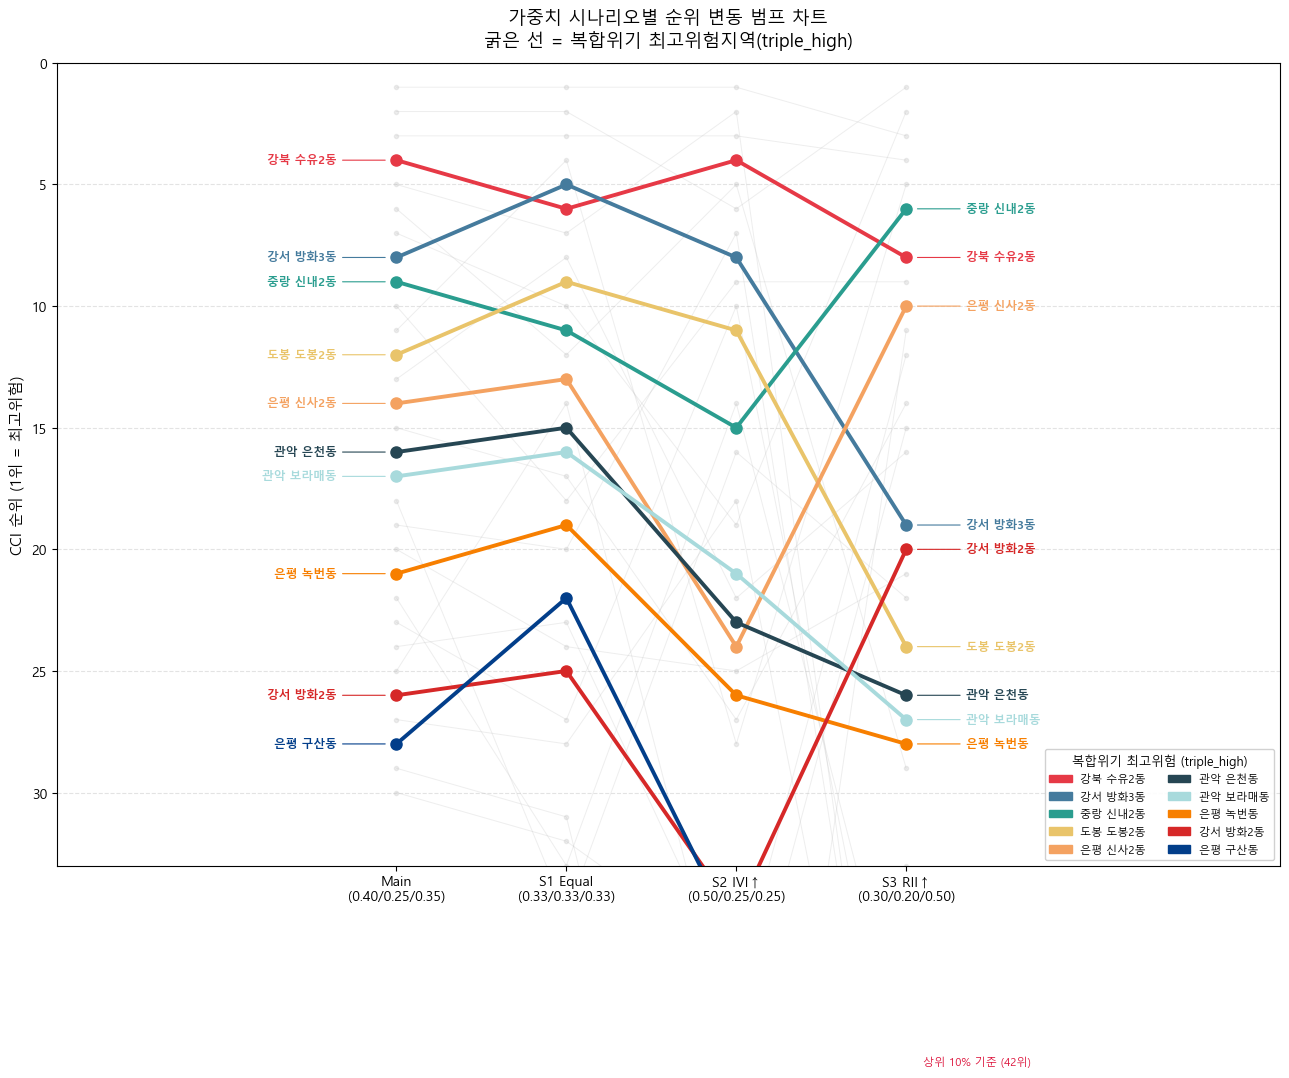

저장: c:\Tsum2026\T_SUM2026\outputs\figures\sensitivity_bump_chart.png


In [6]:
TRACK_N = 30
track_dongs = result.nsmallest(TRACK_N, 'rank_Main')['dong_label'].tolist()
triple_set  = set(result[result['triple_high_flag'] == 1]['dong_label'].values)

PALETTE = [
    '#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261',
    '#264653','#A8DADC','#F77F00','#D62828','#023E8A','#80B918',
]
triple_ordered = [d for d in track_dongs if d in triple_set]
color_map = {d: PALETTE[i % len(PALETTE)] for i, d in enumerate(triple_ordered)}

x_labels = [SCENARIOS[k]['label'] for k in SCENARIOS]
x_pos    = list(range(len(SCENARIOS)))

fig, ax = plt.subplots(figsize=(13, 11))

for dong in track_dongs:
    ranks     = [result.loc[result['dong_label'] == dong, f'rank_{k}'].values[0] for k in SCENARIOS]
    is_triple = dong in triple_set
    color     = color_map.get(dong, '#BBBBBB')
    lw, alpha, ms, zo = (2.8, 1.0, 8, 5) if is_triple else (0.7, 0.25, 3, 2)

    ax.plot(x_pos, ranks, 'o-', color=color, linewidth=lw,
            markersize=ms, alpha=alpha, zorder=zo)

    if is_triple:
        ax.annotate(dong, xy=(-0.05, ranks[0]), xytext=(-0.35, ranks[0]),
                    ha='right', va='center', fontsize=8.5, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8))
        ax.annotate(dong, xy=(x_pos[-1] + 0.05, ranks[-1]), xytext=(x_pos[-1] + 0.35, ranks[-1]),
                    ha='left', va='center', fontsize=8.5, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8))

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_xlim(-2.0, len(x_pos) + 1.2)
ax.invert_yaxis()
ax.set_ylim(TRACK_N + 3, 0)
ax.set_ylabel('CCI 순위 (1위 = 최고위험)', fontsize=11)
ax.set_title('가중치 시나리오별 순위 변동 범프 차트\n굵은 선 = 복합위기 최고위험지역(triple_high)',
             fontsize=13, pad=12)
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.grid(axis='y', linestyle='--', alpha=0.35)

# 상위 10% 기준선
ax.axhline(y=TOP_10PCT, color='crimson', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(x_pos[-1] + 0.1, TOP_10PCT - 0.8,
        f'상위 10% 기준 ({TOP_10PCT}위)', color='crimson', fontsize=8, ha='left')

legend_handles = [mpatches.Patch(color=color_map[d], label=d) for d in triple_ordered]
ax.legend(handles=legend_handles, title='복합위기 최고위험 (triple_high)',
          loc='lower right', fontsize=8, title_fontsize=9,
          framealpha=0.9, ncol=2)

plt.tight_layout()
path_bump = FIG_DIR / 'sensitivity_bump_chart.png'
plt.savefig(path_bump, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_bump}')

---
## 7. 순위 안정성 테이블 — triple_high 11개 동

In [7]:
tri = result[result['triple_high_flag'] == 1].copy().sort_values('rank_Main')
tri['순위_최고'] = tri[rank_cols].min(axis=1)
tri['순위_최저'] = tri[rank_cols].max(axis=1)
tri['순위_변동폭'] = tri['순위_최저'] - tri['순위_최고']
tri['항상_10%이내'] = (tri[rank_cols] <= TOP_10PCT).all(axis=1)

print('=== triple_high 11개 동 — 시나리오별 순위 안정성 ===')
display(tri[['자치구명','행정동명','IVI','CDI','RII'] + rank_cols +
            ['순위_최고','순위_최저','순위_변동폭','항상_10%이내']].round(3).reset_index(drop=True))
print()
print(f'항상 상위 10% 유지: {tri["항상_10%이내"].sum()}/{len(tri)}개')
print(f'평균 순위 변동폭: {tri["순위_변동폭"].mean():.1f}위')
print(f'최대 순위 변동폭: {tri["순위_변동폭"].max()}위 ({tri.loc[tri["순위_변동폭"].idxmax(), "dong_label"]})')

=== triple_high 11개 동 — 시나리오별 순위 안정성 ===


,자치구명,행정동명,IVI,CDI,RII,rank_Main,rank_S1,rank_S2,rank_S3,순위_최고,순위_최저,순위_변동폭,항상_10%이내
0,강북구,수유2동,0.685,0.776,0.447,4,6,4,8,4,8,4,True
1,강서구,방화3동,0.574,0.930,0.411,8,5,8,19,5,19,14,True
2,중랑구,신내2동,0.571,0.774,0.524,9,11,15,6,6,15,9,True
3,도봉구,도봉2동,0.570,0.928,0.392,12,9,11,24,9,24,15,True
4,은평구,신사2동,0.528,0.822,0.505,14,13,24,10,10,24,14,True
5,관악구,은천동,0.581,0.807,0.431,16,15,23,26,15,26,11,True
6,관악구,보라매동,0.589,0.794,0.431,17,16,21,27,16,27,11,True
7,은평구,녹번동,0.552,0.812,0.445,21,19,26,28,19,28,9,True
8,강서구,방화2동,0.522,0.768,0.491,26,25,35,20,20,35,15,True
9,은평구,구산동,0.511,0.846,0.431,28,22,36,34,22,36,14,True



항상 상위 10% 유지: 10/11개
평균 순위 변동폭: 11.2위
최대 순위 변동폭: 15위 (도봉 도봉2동)


---
## 8. 히트맵 — 상위 50개 동 시나리오별 순위

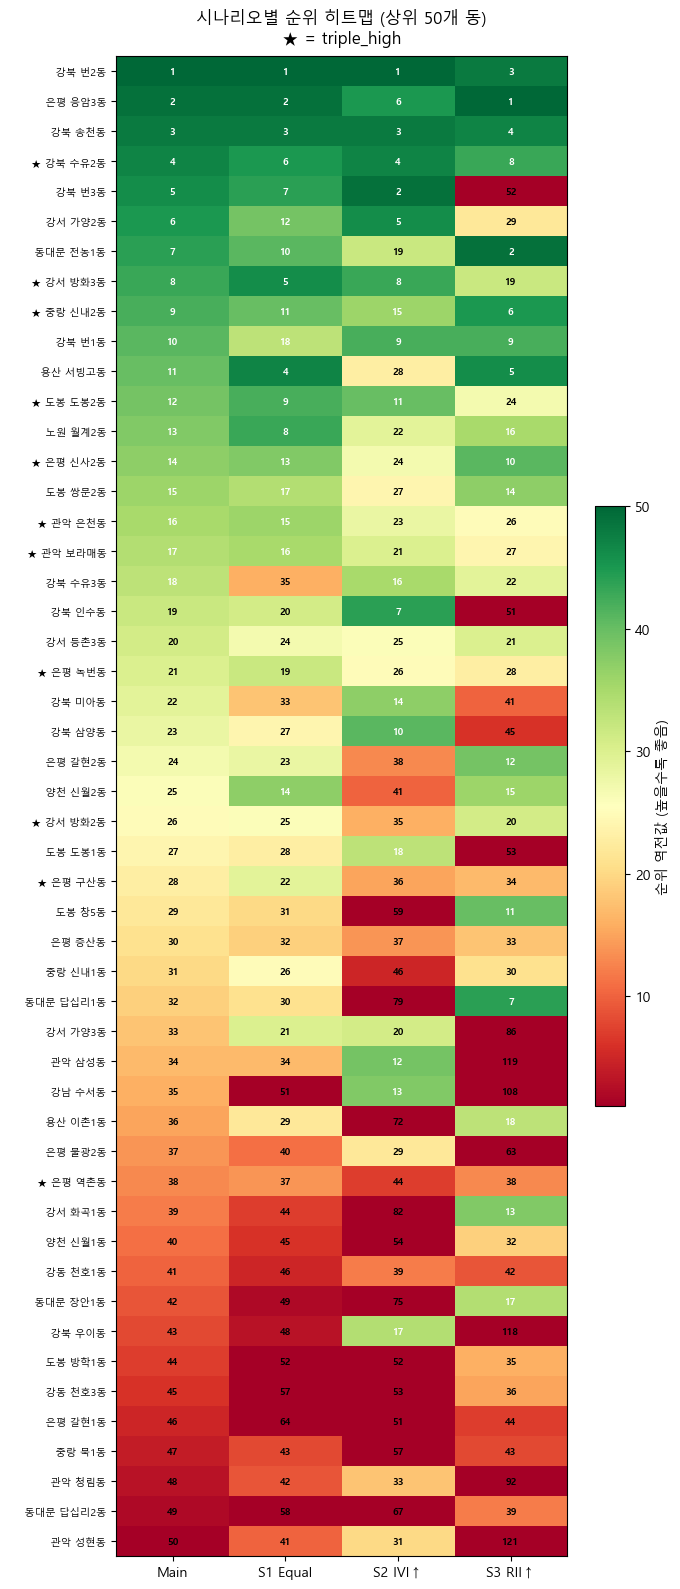

저장: c:\Tsum2026\T_SUM2026\outputs\figures\sensitivity_heatmap.png


In [8]:
TOP_HEAT = 50
heat = result.nsmallest(TOP_HEAT, 'rank_Main')[['dong_label'] + rank_cols].set_index('dong_label')
heat.columns = [SCENARIOS[k]['label'].replace('\n',' ').split('(')[0].strip() for k in SCENARIOS]

fig, ax = plt.subplots(figsize=(7, 16))
heat_vals = TOP_HEAT + 1 - heat.values
im = ax.imshow(heat_vals, cmap='RdYlGn', aspect='auto', vmin=1, vmax=TOP_HEAT)

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=10)
ax.set_yticks(range(len(heat.index)))
ylabels = [f'★ {d}' if d in triple_set else f'    {d}' for d in heat.index]
ax.set_yticklabels(ylabels, fontsize=7.5)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        rank_val = int(heat.values[i, j])
        txt_color = 'white' if heat_vals[i, j] > TOP_HEAT * 0.65 else 'black'
        ax.text(j, i, str(rank_val), ha='center', va='center',
                fontsize=7, color=txt_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='순위 역전값 (높을수록 좋음)', shrink=0.4)
ax.set_title(f'시나리오별 순위 히트맵 (상위 {TOP_HEAT}개 동)\n★ = triple_high',
             fontsize=12, pad=10)
plt.tight_layout()
path_heat = FIG_DIR / 'sensitivity_heatmap.png'
plt.savefig(path_heat, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_heat}')

---
## 9. 최종 요약

In [9]:
print('=' * 60)
print('CCI 민감도 분석 요약')
print('=' * 60)
print()
print('[Kendall τ — Main vs 각 시나리오]')
for k in list(SCENARIOS.keys())[1:]:
    tau, _ = kendalltau(result['rank_Main'], result[f'rank_{k}'])
    print(f'  Main vs {k}: τ = {tau:.3f}')
print()
print(f'[불변의 위험 지역] 모든 시나리오 상위 {TOP_10PCT}위 이내: {len(invariant)}개')
for d in sorted(invariant): print(f'  - {d}')
print()
print('[triple_high 11개 동 유지율 — 각 시나리오 상위 30위 대비]')
for k, w in SCENARIOS.items():
    top30 = set(result[result[f'rank_{k}'] <= 30]['dong_label'])
    kept  = main_triple & top30
    print(f'  {w["label"].replace(chr(10)," "):30s}: {len(kept)}/{len(main_triple)}개 ({len(kept)/len(main_triple)*100:.0f}%)')
print()
print('결론: Kendall τ > 0.80이면 가중치 변화에 관계없이 핵심 고위험 지역의 순위는 안정적입니다.')

CCI 민감도 분석 요약

[Kendall τ — Main vs 각 시나리오]
  Main vs S1: τ = 0.884
  Main vs S2: τ = 0.853
  Main vs S3: τ = 0.794

[불변의 위험 지역] 모든 시나리오 상위 42위 이내: 25개
  - 강북 미아동
  - 강북 번1동
  - 강북 번2동
  - 강북 송천동
  - 강북 수유2동
  - 강북 수유3동
  - 강서 가양2동
  - 강서 등촌3동
  - 강서 방화2동
  - 강서 방화3동
  - 관악 보라매동
  - 관악 은천동
  - 노원 월계2동
  - 도봉 도봉2동
  - 도봉 쌍문2동
  - 동대문 전농1동
  - 양천 신월2동
  - 용산 서빙고동
  - 은평 갈현2동
  - 은평 구산동
  - 은평 녹번동
  - 은평 신사2동
  - 은평 응암3동
  - 은평 증산동
  - 중랑 신내2동

[triple_high 11개 동 유지율 — 각 시나리오 상위 30위 대비]
  Main (0.40/0.25/0.35)         : 10/11개 (91%)
  S1 Equal (0.33/0.33/0.33)     : 10/11개 (91%)
  S2 IVI↑ (0.50/0.25/0.25)      : 8/11개 (73%)
  S3 RII↑ (0.30/0.20/0.50)      : 9/11개 (82%)

결론: Kendall τ > 0.80이면 가중치 변화에 관계없이 핵심 고위험 지역의 순위는 안정적입니다.
